<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/An_EfficientNetB3_Based_Transfer_Learning_Framework_on_the_PAD_UFES_20_Dataset(2nd).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

In [3]:
train_path = "/content/drive/MyDrive/SkinCancer_Split/train"
test_path = "/content/drive/MyDrive/SkinCancer_Split/test"

In [4]:
IMG_SIZE = 300
BATCH_SIZE = 32

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [6]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 1838 images belonging to 6 classes.
Found 460 images belonging to 6 classes.
{'ACK': 0, 'BCC': 1, 'MEL': 2, 'NEV': 3, 'SCC': 4, 'SEK': 5}


In [7]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

# Freeze all except the last 80 layers
for layer in base_model.layers[:-80]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(inputs=input_layer, outputs=output)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 11,706,421 (44.66 MB)

 Trainable params: 7,670,798 (29.26 MB)

 Non-trainable params: 4,035,623 (15.39 MB)

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.5245433789954338), 1: np.float64(0.4531558185404339), 2: np.float64(7.2936507936507935), 3: np.float64(1.570940170940171), 4: np.float64(2.002178649237473), 5: np.float64(1.6294326241134751)}


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
callbacks = [

    EarlyStopping(
        patience=6,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        factor=0.3,
        patience=3
    ),

    ModelCheckpoint(
        "/content/drive/MyDrive/best_model_skin_cancer.keras",
        save_best_only=True
    )
]

In [12]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1022s 17s/step - accuracy: 0.2182 - loss: 2.3937 - val_accuracy: 0.2217 - val_loss: 1.8325 - learning_rate: 5.0000e-05
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 916s 16s/step - accuracy: 0.2720 - loss: 2.0633 - val_accuracy: 0.3630 - val_loss: 1.7513 - learning_rate: 5.0000e-05
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 907s 15s/step - accuracy: 0.3324 - loss: 1.7245 - val_accuracy: 0.4000 - val_loss: 1.6767 - learning_rate: 5.0000e-05
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 940s 16s/step - accuracy: 0.3629 - loss: 1.5886 - val_accuracy: 0.4130 - val_loss: 1.5852 - learning_rate: 5.0000e-05
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 896s 15s/step - accuracy: 0.4162 - loss: 1.4191 - val_accuracy: 0.4565 - val_loss: 1.4687 - learning_rate: 5.0000e-05
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 930s 16s/step - accuracy: 0.4690 - loss: 1.2897 - val_accuracy: 0.5000 - val_loss: 1.3722 - learning_rate: 5.0000e-05
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 915s 15s/step - accuracy:

In [13]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss :", round(loss,4))
print("Test Accuracy :", round(accuracy*100,2), "%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 136s 9s/step - accuracy: 0.5435 - loss: 1.2120
Test Loss : 1.212
Test Accuracy : 54.35 %


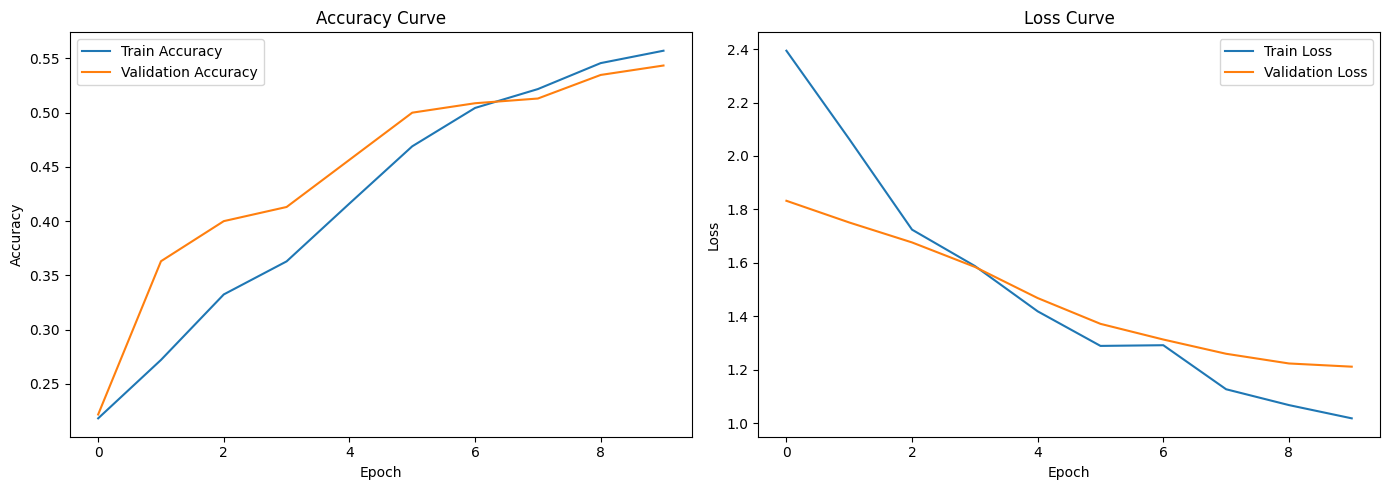

In [14]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(class_names)

15/15 ━━━━━━━━━━━━━━━━━━━━ 150s 9s/step
['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']


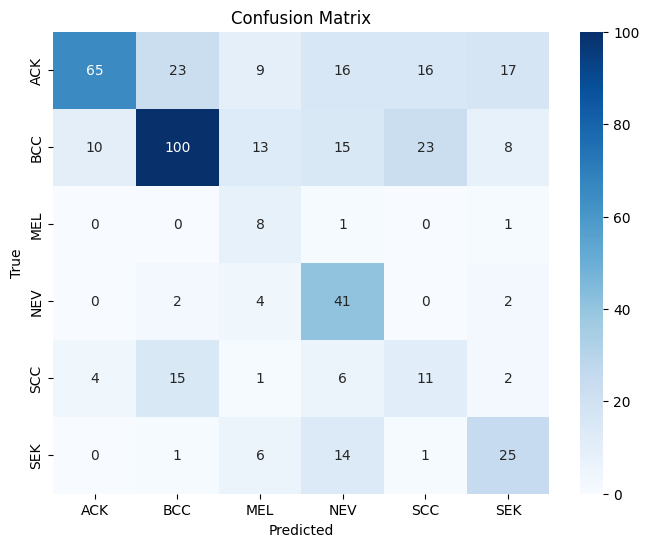

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [17]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

         ACK       0.82      0.45      0.58       146
         BCC       0.71      0.59      0.65       169
         MEL       0.20      0.80      0.31        10
         NEV       0.44      0.84      0.58        49
         SCC       0.22      0.28      0.24        39
         SEK       0.45      0.53      0.49        47

    accuracy                           0.54       460
   macro avg       0.47      0.58      0.47       460
weighted avg       0.64      0.54      0.56       460



In [18]:
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision :", round(precision*100,2), "%")
print("Recall    :", round(recall*100,2), "%")
print("F1 Score  :", round(f1*100,2), "%")

Precision : 63.76 %
Recall    : 54.35 %
F1 Score  : 55.96 %


In [19]:
n_classes = len(class_names)

y_true_bin = label_binarize(
    y_true,
    classes=range(n_classes)
)

In [20]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

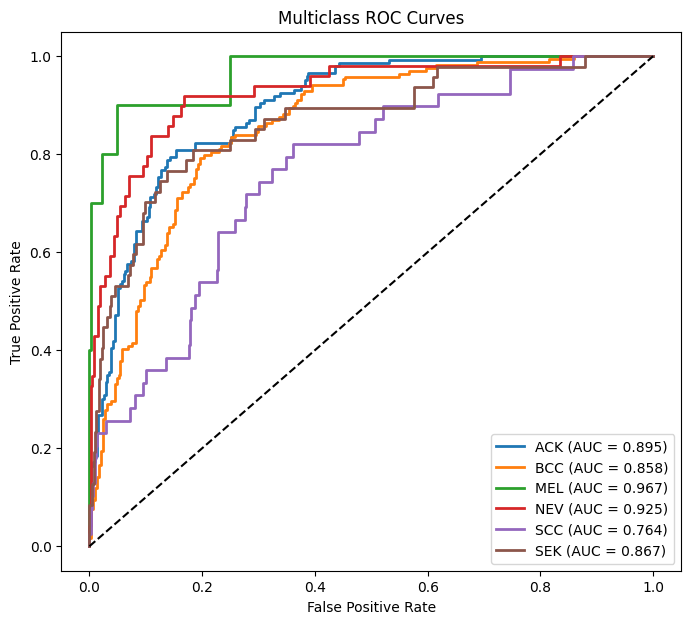

In [21]:
plt.figure(figsize=(8,7))

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")

plt.legend()

plt.show()

In [23]:
print("\nAUC Values")

for i in range(n_classes):

    print(
        class_names[i],
        ":",
        round(roc_auc[i],4)
    )


AUC Values
ACK : 0.8954
BCC : 0.8579
MEL : 0.9673
NEV : 0.9251
SCC : 0.7642
SEK : 0.8667


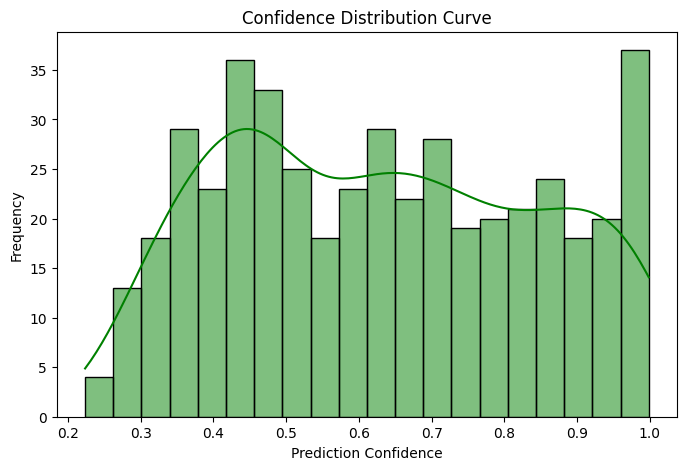

In [24]:
confidence_scores = np.max(
    y_pred_prob,
    axis=1
)

plt.figure(figsize=(8,5))

sns.histplot(
    confidence_scores,
    bins=20,
    kde=True,
    color='green'
)

plt.xlabel("Prediction Confidence")

plt.ylabel("Frequency")

plt.title("Confidence Distribution Curve")

plt.show()